In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project Objective

The goal of this analysis was to understand shopping behavior patterns using statistical exploration, focusing on:

- distribution structure

- customer segmentation

- temporal dynamics

- interaction patterns

- payment behavior

In [2]:
df = pd.read_csv(r"/kaggle/input/datasets/faresashraf1001/supermarket-sales/SuperMarket Analysis.csv")

df.head(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,Giza,Naypyitaw,Member,Female,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,6:30:00 PM,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,Alex,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2/25/2019,2:36:00 PM,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,Giza,Naypyitaw,Member,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38:00 AM,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,Alex,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.1460,1/10/2019,5:15:00 PM,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,Cairo,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.7460,2/20/2019,1:27:00 PM,Credit card,164.52,4.761905,8.2260,5.9


In [3]:
df.shape

(1000, 17)

In [4]:
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [5]:
df["Invoice ID"].nunique()

1000

One row represents one complete purchase = one invoice  →  because total rows = number of unique invoices

So:

Mean(Sales) → average basket value

Median(Sales) → typical basket

Outliers → unusually large purchases

In [6]:
sales_mean = df['Sales'].mean()
sales_median = df['Sales'].median()

print(f'Average sale has value of {sales_mean} and a typical basket has value of {sales_median}')

Average sale has value of 322.966749 and a typical basket has value of 253.848


In [7]:
df['Sales'].skew().round(2)

np.float64(0.89)

How to interpret skew ≈ 0.89

Skewness	Interpretation
~0	        symmetric
0.3 – 0.7	mild right skew
0.7 – 1.5	moderate right skew
>2	        strong long tail

<Axes: >

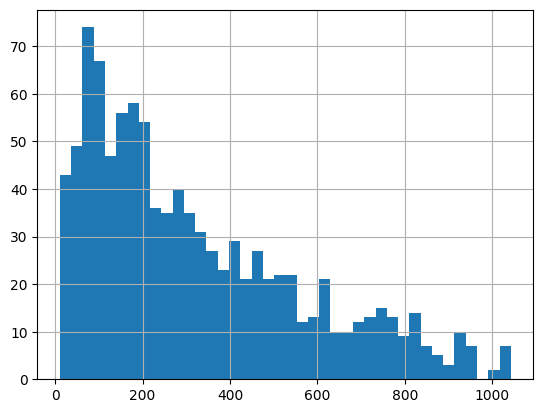

In [8]:
df['Sales'].hist(bins=40)

<Axes: >

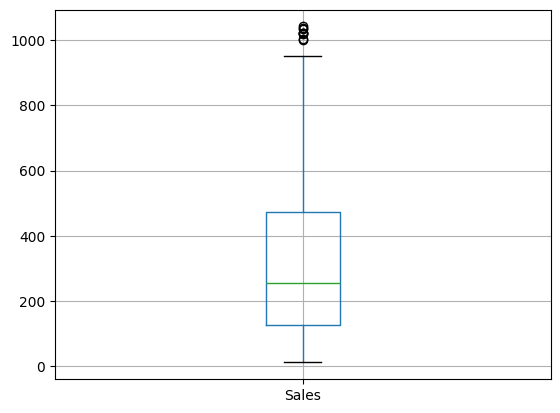

In [9]:
df.boxplot(column='Sales')

Conclusions:
- Retail baskets are right-skewed, but not extreme
- Most customers behave similarly
- The mean being larger than the median indicates the presence of outliers that we see clearly in the boxplot -> there are big purchases


Let's check what the situation looks it with products

# Product line analysis

In [10]:
by_product = df.groupby('Product line').agg(
    nb_invoices=('Invoice ID', 'count'),
    median_sales=('Sales', 'median'),
    mean_sales =('Sales', 'mean'),
    std_sales= ('Sales', 'std')
).sort_values("median_sales", ascending=False).round(2)

by_product

,nb_invoices,median_sales,mean_sales,std_sales
Product line,,,,
Health and beauty,152,272.31,323.64,237.54
Sports and travel,166,270.93,332.07,248.38
Home and lifestyle,160,258.19,336.64,254.60
Food and beverages,174,252.49,322.67,247.16
Electronic accessories,170,241.22,319.63,245.95
Fashion accessories,178,211.65,305.09,243.56


Conclusions:

- Health and beauty and Sports and travel sit at the top -> customers usually spend more per transaction in these categories
- Home and lifestyle has a big difference beween the median and the mean -> this category likely has some very large baskets pulling the average up
- Home and lifestyle - the biggest standard deviation -> basket values vary a lot in this category

In [11]:
by_product["mean_minus_median"] = (
    by_product["mean_sales"] - by_product["median_sales"]
)

by_product.sort_values("mean_minus_median", ascending=False)

,nb_invoices,median_sales,mean_sales,std_sales,mean_minus_median
Product line,,,,,
Fashion accessories,178,211.65,305.09,243.56,93.44
Home and lifestyle,160,258.19,336.64,254.60,78.45
Electronic accessories,170,241.22,319.63,245.95,78.41
Food and beverages,174,252.49,322.67,247.16,70.18
Sports and travel,166,270.93,332.07,248.38,61.14
Health and beauty,152,272.31,323.64,237.54,51.33


Fashion accessories have the biggest difference between the mean and the median -> baskets values vary a lot, most purchases are small, but large baskets pull the mean up.
Very unstable category. 

We suspect big baskets are driving the gaps.

Let’s measure it directly



Task - Compute the % of “large transactions” per product line

Define large as: sales above overall 75th percentile

In [12]:
cut = df["Sales"].quantile(0.75)

df["is_large"] = False
df.loc[df["Sales"] > cut, "is_large"] = True

df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,is_large
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,True
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,False
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,False
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,True
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,True


In [13]:
large_rate = df.groupby('Product line')['is_large'].mean().sort_values(ascending=False).round(3)

large_rate

Product line
Health and beauty         0.270
Home and lifestyle        0.269
Sports and travel         0.253
Electronic accessories    0.253
Fashion accessories       0.230
Food and beverages        0.230
Name: is_large, dtype: float64

Conclusions:

Earlier we suspected that fashion accessories might dominate large baskets because it had the biggest mean–median gap.

But now we see it’s NOT the highest in large purchase rate, the first place belongs to Health and Beauty. This is the category with the biggest percentage of large baskets. 

Correlation table

In [14]:
num_cols = df.select_dtypes(include="number")

corr = num_cols.corr()

corr["Sales"].sort_values(ascending=False).round(2)

Sales                      1.00
gross income               1.00
Tax 5%                     1.00
cogs                       1.00
Quantity                   0.71
Unit price                 0.63
Rating                    -0.04
gross margin percentage     NaN
Name: Sales, dtype: float64

Quantity and Unit price have interesting correllations

Bigger quantities → larger baskets
Higher-priced items → larger baskets

Let's remove structural correllations

In [15]:
behavior_cols = num_cols.drop(columns=["Tax 5%", "gross income", "cogs"])

behavior_corr = behavior_cols.corr()

behavior_corr["Sales"].sort_values(ascending=False).round(2)

Sales                      1.00
Quantity                   0.71
Unit price                 0.63
Rating                    -0.04
gross margin percentage     NaN
Name: Sales, dtype: float64

- Quantity (0.71) — Strongest behavioral driver - larger baskets mostly come from buying more items
- Unit price (0.63) — Also important, both price and volume matter — but volume dominates slightly
- Rating (-0.04) — Essentially zero, higher satisfaction scores do NOT translate into larger basket values

Why is “gross margin percentage” NaN?
- Because that column has no variation, the value is identical everywhere


In [16]:
df['gross margin percentage'].nunique()

1

# Comparing Members vs Normal Customers

In [17]:
membership = df.groupby("Customer type")["Sales"].agg(
    ["count","median","mean","std"]
).round(2)

membership

,count,median,mean,std
Customer type,,,,
Member,565,271.95,335.74,250.42
Normal,435,225.79,306.37,239.14


In [18]:
membership['mean_median_difference'] = membership['mean'] - membership['median']

membership

,count,median,mean,std,mean_median_difference
Customer type,,,,,
Member,565,271.95,335.74,250.42,63.79
Normal,435,225.79,306.37,239.14,80.58


Members have a higher median (≈272 vs 226)
-> Members typically spend more per transaction

Mean-median gap for normal customers ≈80.58:
-> Normal customers rely more on occasional big purchases

In [19]:
mix = df.groupby(['Customer type', 'Product line']).size().unstack()

mix

Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Customer type,,,,,,
Member,90,96,104,86,92,97
Normal,80,82,70,66,68,69


In [20]:
mix_pct = mix / mix.sum(axis=1).values.reshape(-1,1)

mix_pct.round(2)

Product line,Electronic accessories,Fashion accessories,Food and beverages,Health and beauty,Home and lifestyle,Sports and travel
Customer type,,,,,,
Member,0.16,0.17,0.18,0.15,0.16,0.17
Normal,0.18,0.19,0.16,0.15,0.16,0.16


There are small differences:

- Normal customers spend slightly higher in Electronic & Fashion

- Member slightly higher in Food & Sports

But the differences are very small, so we cannot say that members are spending more just because they buy different categories.

# Comparing Members vs Normal inside each product line.

In [21]:
within_cat = df.groupby(["Product line","Customer type"])["Sales"].median().unstack().round(2)

within_cat

Customer type,Member,Normal
Product line,,
Electronic accessories,248.60,229.67
Fashion accessories,242.46,209.15
Food and beverages,269.90,229.22
Health and beauty,291.61,217.41
Home and lifestyle,266.57,247.46
Sports and travel,282.49,226.06


In [22]:
df.groupby("Customer type")[["Quantity","Unit price"]].median()

,Quantity,Unit price
Customer type,,
Member,6.0,56.69
Normal,5.0,52.60


Now we see that:

- Members buy more items
- Members buy slightly more expensive items

# Comparing variability (std) by customer type

In [23]:
df.groupby("Customer type")[["Quantity","Unit price"]].std().round(2)

,Quantity,Unit price
Customer type,,
Member,2.96,26.77
Normal,2.88,26.10


Members are slightly more variable in both:

- how many items they buy
- how expensive those items are

But the differences are very small, so we cannot call them unpredictable, just having a different behavior ranges

# Where does MOST revenue actually come from?

In [24]:
df_sorted = df.sort_values("Sales", ascending=False)

df_sorted[["Customer type","Product line","Sales"]].head(10)

,Customer type,Product line,Sales
350,Member,Fashion accessories,1042.650
167,Normal,Fashion accessories,1039.290
557,Member,Food and beverages,1034.460
699,Normal,Home and lifestyle,1023.750
996,Normal,Home and lifestyle,1022.490
792,Normal,Home and lifestyle,1022.385
422,Member,Fashion accessories,1020.705
166,Normal,Home and lifestyle,1003.590
357,Normal,Sports and travel,1002.120
429,Member,Home and lifestyle,951.825


In [25]:
df_sorted["cum_sales"] = df_sorted["Sales"].cumsum().round(2)
df_sorted["cum_pct"] = (df_sorted["cum_sales"] / df_sorted["Sales"].sum()).round(2)

df_sorted.head(10)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,is_large,cum_sales,cum_pct
350,860-79-0874,Giza,Naypyitaw,Member,Female,Fashion accessories,99.30,10,49.650,1042.650,2/15/2019,2:53:00 PM,Credit card,993.0,4.761905,49.650,6.6,True,1042.65,0.00
167,687-47-8271,Alex,Yangon,Normal,Male,Fashion accessories,98.98,10,49.490,1039.290,2/8/2019,4:20:00 PM,Credit card,989.8,4.761905,49.490,8.7,True,2081.94,0.01
557,283-26-5248,Giza,Naypyitaw,Member,Female,Food and beverages,98.52,10,49.260,1034.460,1/30/2019,8:23:00 PM,Ewallet,985.2,4.761905,49.260,4.5,True,3116.40,0.01
699,751-41-9720,Giza,Naypyitaw,Normal,Male,Home and lifestyle,97.50,10,48.750,1023.750,1/12/2019,4:18:00 PM,Ewallet,975.0,4.761905,48.750,8.0,True,4140.15,0.01
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.690,1022.490,3/2/2019,5:16:00 PM,Ewallet,973.8,4.761905,48.690,4.4,True,5162.64,0.02
792,744-16-7898,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.37,10,48.685,1022.385,1/15/2019,1:48:00 PM,Credit card,973.7,4.761905,48.685,4.9,True,6185.02,0.02
422,271-88-8734,Giza,Naypyitaw,Member,Female,Fashion accessories,97.21,10,48.605,1020.705,2/8/2019,1:00:00 PM,Credit card,972.1,4.761905,48.605,8.7,True,7205.73,0.02
166,234-65-2137,Giza,Naypyitaw,Normal,Male,Home and lifestyle,95.58,10,47.790,1003.590,1/16/2019,1:32:00 PM,Cash,955.8,4.761905,47.790,4.8,True,8209.32,0.03
357,554-42-2417,Giza,Naypyitaw,Normal,Female,Sports and travel,95.44,10,47.720,1002.120,1/9/2019,1:45:00 PM,Cash,954.4,4.761905,47.720,5.2,True,9211.44,0.03
429,325-77-6186,Alex,Yangon,Member,Female,Home and lifestyle,90.65,10,45.325,951.825,3/8/2019,10:53:00 AM,Ewallet,906.5,4.761905,45.325,7.3,True,10163.27,0.03


# How many invoices generate the first 80% of revenue?

In [26]:
df_sorted[df_sorted["cum_pct"] <= 0.80].shape

(503, 20)

Roughly 50% of invoices make for 80% of the total revenue

# Date / Time Behavior Analysis

In [27]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour
df.groupby("Hour")["Sales"].median().round(2).sort_values(ascending=False)

/tmp/ipykernel_17/3247268347.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


Hour
19    328.76
14    321.77
16    290.08
17    272.19
13    271.28
11    252.29
15    234.65
10    216.44
20    212.78
12    203.93
18    197.92
Name: Sales, dtype: float64

In [28]:
df['Day'] = pd.to_datetime(df['Date']).dt.weekday
df.groupby('Day')['Sales'].median().round(2).sort_values(ascending=False)

Day
5    298.84
6    290.08
3    271.91
4    241.46
0    237.43
1    213.11
2    209.62
Name: Sales, dtype: float64

In [29]:
df.groupby(['Day', 'Hour']).agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean')
).round(2).sort_values('median', ascending=False).head(15)

nb_invoices  median    mean
Day Hour                             
1   15             14  581.19  501.44
6   11             11  494.76  430.62
5   14             11  442.32  485.62
    13             14  431.05  406.40
4   19             13  427.81  421.23
3   10             18  419.83  382.51
    20             10  402.36  452.52
1   16              9  395.89  425.72
5   11             12  395.30  457.24
0   14              6  390.66  334.06
3   14             14  387.33  391.00
0   12             14  386.00  337.58
5   19             23  384.47  396.41
6   17             11  369.68  379.03
5   18             18  358.72  374.38

Important conclusion : these are small sample sizes.

Out of ~1000 invoices total, groups of 11–14 transactions are tiny slices, which suggests local spikes, not a business pattern.

So far: 

- Weekends have strong medians broadly

- Evenings often strong

- Some weekday afternoons produce large baskets

This hints at:

- Two different shopping behaviors:

a. Planned weekend bulk shopping
b. Targeted weekday afternoon purchases

# Weekends

In [30]:
weekends = df[(df['Day'] == 5) | (df['Day'] == 6)]

weekends.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,is_large,Hour,Day
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,True,13,5
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,False,13,6
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,True,20,6
7,315-22-5665,Giza,Naypyitaw,Member,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2/24/2019,11:38:00 AM,Ewallet,735.60,4.761905,36.7800,8.0,True,11,6
11,529-56-3974,Cairo,Mandalay,Member,Female,Electronic accessories,25.51,4,5.1020,107.1420,3/9/2019,5:03:00 PM,Cash,102.04,4.761905,5.1020,6.8,False,17,5


In [31]:
weekend_summary = weekends.groupby('Product line').agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean')
).round(2).sort_values('median', ascending=False)

weekend_summary.head(10)

,nb_invoices,median,mean
Product line,,,
Health and beauty,33,374.41,375.26
Home and lifestyle,56,327.29,380.01
Sports and travel,52,303.14,331.87
Food and beverages,54,264.83,317.39
Electronic accessories,47,259.77,343.75
Fashion accessories,55,252.76,297.50


In [32]:
weekend_summary['mean_median_difference'] = weekend_summary['mean'] - weekend_summary['median'].round(2)

weekend_summary.head(10)

,nb_invoices,median,mean,mean_median_difference
Product line,,,,
Health and beauty,33,374.41,375.26,0.85
Home and lifestyle,56,327.29,380.01,52.72
Sports and travel,52,303.14,331.87,28.73
Food and beverages,54,264.83,317.39,52.56
Electronic accessories,47,259.77,343.75,83.98
Fashion accessories,55,252.76,297.50,44.74


 - Weekend purchases in Health and beauty are very consistent, the mean and median difference is almost nothing
 - Electronic accessories, Food & beverages, Home & lifestyle are driven by fewer large purchases, as the mean and median differences are significant

Conclusions: 
- Weekends don’t affect all categories equally.
- Some categories become consistently stronger (Health & beauty)
- Others become more volatile (Electronics)


Weekend strength is mostly driven by occasional large purchases across several categories, while Health & Beauty stands out as consistently high-value shopping rather than spike-driven behavior.

# Weekdays

Questions to inspect:
- Does Health & Beauty stay strong on weekdays? Weekend effect might not be special — just amplification
- What other categories come strong during weeekdays? 

In [33]:
week = df[(df['Day'] != 5) & (df['Day'] != 6)]

week.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,is_large,Hour,Day
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,False,10,4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,True,10,4
5,699-14-3026,Giza,Naypyitaw,Member,Female,Electronic accessories,85.39,7,29.8865,627.6165,3/25/2019,6:30:00 PM,Ewallet,597.73,4.761905,29.8865,4.1,True,18,0
6,355-53-5943,Alex,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2/25/2019,2:36:00 PM,Ewallet,413.04,4.761905,20.6520,5.8,False,14,0
8,665-32-9167,Alex,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.1460,1/10/2019,5:15:00 PM,Credit card,72.52,4.761905,3.6260,7.2,False,17,3


In [34]:
week_summary = week.groupby('Product line').agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean')
).round(2).sort_values('median', ascending=False)

week_summary.head(10)

,nb_invoices,median,mean
Product line,,,
Health and beauty,119,262.79,309.33
Food and beverages,120,252.49,325.05
Sports and travel,114,235.05,332.16
Home and lifestyle,104,228.62,313.28
Electronic accessories,123,222.14,310.42
Fashion accessories,123,209.62,308.48


In [35]:
week_summary['mean_median_difference'] = week_summary['mean'] - week_summary['median'].round(2)

week_summary.head(10)

,nb_invoices,median,mean,mean_median_difference
Product line,,,,
Health and beauty,119,262.79,309.33,46.54
Food and beverages,120,252.49,325.05,72.56
Sports and travel,114,235.05,332.16,97.11
Home and lifestyle,104,228.62,313.28,84.66
Electronic accessories,123,222.14,310.42,88.28
Fashion accessories,123,209.62,308.48,98.86


 - Health & Beauty is no longer “purely consistent” during weekdays, the mean and median difference is now noticeable --> Weekends change HOW people buy this category — not just how much
 - Weekday shopping is more spike-driven across almost all categories

Conclusions:

Weekdays
- quick stops

- occasional big purchases

- higher variability

- more “errand-style” shopping

Weekends

- planned shopping

- consistent basket sizes

- bulk purchases

Members → historically more consistent spenders

Let's analyse what is looks like date/time wise

In [36]:
weekend_customer = weekends.groupby('Customer type').agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean')
).round(2).sort_values('median', ascending=False)

weekend_customer

,nb_invoices,median,mean
Customer type,,,
Member,168,309.88,358.43
Normal,129,259.77,312.89


Key observations:

- Members still have a higher typical basket on weekends, also they buy more
- This matches the overall pattern we saw earlier

In [37]:
week_customer = week.groupby('Customer type').agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean')
).round(2).sort_values('median', ascending=False)

week_customer

,nb_invoices,median,mean
Customer type,,,
Member,397,252.04,326.14
Normal,306,217.44,303.63


- Both customer groups increase their median basket size on weekends.
- Members experience a larger median increase.

Variability

In [38]:
weekends.groupby('Customer type')['Sales'].std().round(2)

Customer type
Member    247.53
Normal    240.22
Name: Sales, dtype: float64

In [39]:
week.groupby('Customer type')['Sales'].std().round(2)

Customer type
Member    251.32
Normal    239.02
Name: Sales, dtype: float64

The spread of basket sizes remains similar, customers maintain similar variability, but their baseline spending increases on weekends

Time analysis weekends

In [40]:
weekend_times = weekends.groupby('Hour').agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean'),
    std=('Sales', 'std')
).round(2).sort_values('median', ascending=False)

weekend_times


,nb_invoices,median,mean,std
Hour,,,,
14,24,416.80,417.42,270.92
11,23,415.23,444.51,284.85
19,40,348.53,377.03,251.32
17,23,333.21,401.70,276.39
16,20,293.60,302.74,234.15
13,32,284.14,339.04,217.66
18,33,279.38,314.43,244.73
10,27,276.95,272.72,189.63
12,29,255.18,332.38,260.20


- 11:00 – 14:00 → very high medians -> weekend late-morning to early-afternoon looks like a sustained high-value shopping window
- 17:00 – 19:00 → strong but slightly lower
- 20:00 → clear drop

In [41]:
weekend_products = weekends.groupby(['Hour', 'Product line']).agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean'),
    std=('Sales', 'std')
).round(2).sort_values('median', ascending=False)

weekend_products.head(24)

,,nb_invoices,median,mean,std
Hour,Product line,,,,
14,Electronic accessories,3,860.68,780.88,202.23
11,Health and beauty,1,760.44,760.44,NaN
18,Home and lifestyle,2,738.56,738.56,70.63
11,Food and beverages,4,694.14,723.02,153.82
12,Health and beauty,2,665.73,665.73,275.41
19,Health and beauty,3,579.84,422.56,340.10
18,Health and beauty,3,545.37,484.34,437.78
17,Fashion accessories,3,536.59,466.48,293.68
13,Fashion accessories,7,495.32,443.58,259.76


TOP 5: 

These are extremely small samples, number of invoices is very low (reminder : 1003 invoices total).
It suggests spike behaviour

19 – Sports & travel → 10 invoices
18 – Electronic accessories → 12 invoices
13 – Fashion accessories → 7 invoices
11 – Home & lifestyle → 7 invoices

They suggest repeatable behavior, the number of invoices is growing

Weekend late-morning to early-afternoon acts as a high-value shopping window where multiple categories show elevated basket sizes.

Weekday times

In [42]:
week_times = week.groupby('Hour').agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean'),
    std=('Sales', 'std')
).round(2).sort_values('median', ascending=False)

week_times

,nb_invoices,median,mean,std
Hour,,,,
14,59,318.11,352.72,270.90
19,73,288.58,337.24,237.97
16,57,288.02,336.34,224.96
13,71,263.97,336.25,278.50
15,79,252.04,316.79,253.94
20,52,248.14,334.38,262.60
17,51,229.11,298.16,226.94
11,67,218.01,300.80,242.33
10,74,213.06,325.11,261.28


In [43]:
week_products = week.groupby(['Hour', 'Product line']).agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean'),
    std=('Sales', 'std')
).round(2).sort_values('median', ascending=False)

week_products.head(24)

nb_invoices  median    mean     std
Hour Product line                                               
11   Food and beverages                7  570.78  503.52  296.69
16   Fashion accessories              10  485.84  475.09  324.49
14   Sports and travel                12  477.29  418.84  318.24
19   Electronic accessories            9  470.67  415.47  296.42
     Home and lifestyle                8  450.22  438.18  203.10
     Sports and travel                10  436.36  436.40  274.45
10   Fashion accessories              11  431.26  474.28  259.85
17   Home and lifestyle                9  430.71  370.93  198.57
14   Home and lifestyle                5  399.76  332.98  212.72
15   Electronic accessories           12  393.62  396.09  271.09
12   Food and beverages                5  374.39  319.97  186.93
16   Food and beverages               11  367.04  345.43  214.63
20   Fashion accessories               4  366.99  323.23  107.13
16   Home and lifestyle                5  352.22  405.04  159.04
14   Food and beverages                7  348.70  439.28  293.10
10   Sports and travel                 9  345.79  362.07  285.43
15   Health and beauty                 8  339.58  375.89  254.79
20   Sports and travel                 4  336.29  341.64  195.93
19   Health and beauty                11  326.26  372.52  249.39
14   Health and beauty                15  318.11  355.67  231.97
13   Fashion accessories              12  317.50  417.03  280.35
18   Sports and travel                 8  293.62  384.40  299.86
17   Health and beauty                 8  287.01  346.02  264.26
     Food and beverages                4  284.80  282.87  171.84

- the hours are more scattered, no visible time cluster
- different categories peak at different hours
- no single shared window dominates strongly

2 PM is interesting because:

- unlike many other weekday hours, we can see multiple categories appearing around 14:00 with:

14 – Sports and travel   (12 invoices)
14 – Home and lifestyle   (5 invoices)
14 – Food and beverages   (7 invoices)
14 – Health and beauty   (15 invoices)

Summary :

Right skew in Sales
→ amplified by weekend baseline shift
→ concentrated further into midday time windows
→ shared across multiple product lines
→ enhanced by Member behavior

What if we try to sort by number of invoices to see where the most traffic is?

In [44]:
week_products = week.groupby(['Hour', 'Product line']).agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean'),
    std=('Sales', 'std')
).round(2).sort_values('nb_invoices', ascending=False)

week_products.head(24)

nb_invoices  median    mean     std
Hour Product line                                               
19   Fashion accessories              19  160.86  260.97  202.94
15   Food and beverages               18  266.00  362.86  281.64
19   Food and beverages               16  193.26  247.10  192.43
10   Electronic accessories           16  167.36  257.26  189.44
     Health and beauty                16  208.78  295.31  282.47
20   Food and beverages               15  248.41  376.02  333.35
13   Home and lifestyle               15  163.00  307.31  335.29
15   Home and lifestyle               15  252.04  298.62  242.74
14   Health and beauty                15  318.11  355.67  231.97
11   Home and lifestyle               14  189.30  269.72  244.33
     Electronic accessories           14  233.24  294.90  216.15
15   Fashion accessories              13   96.58  180.13  226.71
     Sports and travel                13  257.14  301.08  220.70
20   Electronic accessories           13  192.84  334.58  307.75
10   Food and beverages               13  175.92  251.54  224.70
15   Electronic accessories           12  393.62  396.09  271.09
13   Food and beverages               12  222.93  284.26  209.40
     Sports and travel                12  263.40  404.65  336.50
18   Fashion accessories              12  201.08  218.76  179.40
16   Sports and travel                12  200.34  237.87  172.23
13   Fashion accessories              12  317.50  417.03  280.35
14   Sports and travel                12  477.29  418.84  318.24
12   Health and beauty                12  138.95  251.99  191.74
     Fashion accessories              12  259.31  297.64  251.09

The data now hints at two overlapping behavior patterns:

High-value environment (median-driven)
- concentrated around midday
- baskets larger

High-frequency environment (invoice-driven)

- more dispersed
- includes evenings and routine hours
- baskets often smaller or moderate

Operational suggestions:

Operational efficiency should align with high-frequency traffic windows to support routine shopping flow, while promotional efforts may be better targeted toward high-value time blocks where customers are already predisposed to larger baskets.

Weekday payment method analysis

In [45]:
week_payment = week.groupby(['Hour', 'Payment']).agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean'),
    std=('Sales', 'std')
).round(2).sort_values('nb_invoices', ascending=False)

week_payment.head(24)

,,nb_invoices,median,mean,std
Hour,Payment,,,,
10,Credit card,29,149.36,227.50,205.22
15,Ewallet,29,288.20,316.27,220.01
13,Cash,28,299.79,386.12,290.43
16,Ewallet,27,319.79,352.78,197.80
11,Ewallet,27,190.16,267.98,248.97
15,Cash,26,155.12,255.17,259.95
19,Credit card,26,362.42,356.69,206.74
10,Cash,25,313.57,377.97,267.97
15,Credit card,24,356.74,384.18,278.00


- Ewallet appears consistently rather than peaking in just one window, looks like a default / habitual payment.
- credit card is either the very morning, or late evening hours -> planned purchases before work or after work, shoppers may be using it more intentionally, not as a default routine
- cash → mixed usage → less structured pattern

Weekends payment methods analysis

In [46]:
weekends_payment = weekends.groupby(['Hour', 'Payment']).agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean'),
    std=('Sales', 'std')
).round(2).sort_values('median', ascending=False)

weekends_payment.head(24)

nb_invoices  median    mean     std
Hour Payment                                         
11   Credit card            6  626.42  500.21  330.74
     Ewallet                4  471.99  474.45  308.89
14   Credit card            9  435.12  389.29  238.77
20   Cash                   4  429.57  466.84  280.85
16   Ewallet                6  424.02  478.23  302.97
12   Credit card           11  419.83  421.59  321.29
14   Cash                   7  398.48  411.91  285.15
     Ewallet                8  387.46  453.88  322.08
19   Ewallet               18  386.03  400.18  229.32
11   Cash                  13  375.36  409.59  275.96
19   Credit card           10  372.15  398.88  245.99
13   Ewallet               14  372.09  377.89  206.95
17   Cash                   8  354.00  441.82  237.37
18   Credit card           13  337.51  357.95  285.92
10   Cash                  14  328.06  347.84  198.20
12   Cash                   8  296.67  344.26  256.45
13   Cash                  12  284.14  319.81  211.29
17   Ewallet                7  279.18  440.09  333.95
     Credit card            8  259.72  328.00  280.40
15   Credit card            6  257.80  286.23  176.03
18   Cash                  12  251.02  268.32  206.05
     Ewallet                8  237.49  312.84  244.46
15   Cash                   9  234.10  313.55  265.26
16   Cash                   8  227.96  209.89  109.00

In [47]:
weekends_payment = weekends.groupby(['Hour', 'Payment']).agg(
    nb_invoices=('Invoice ID', 'size'),
    median=('Sales', 'median'),
    mean=('Sales', 'mean'),
    std=('Sales', 'std')
).round(2).sort_values('nb_invoices', ascending=False)

weekends_payment.head(24)

,,nb_invoices,median,mean,std
Hour,Payment,,,,
19,Ewallet,18,386.03,400.18,229.32
10,Cash,14,328.06,347.84,198.20
13,Ewallet,14,372.09,377.89,206.95
18,Credit card,13,337.51,357.95,285.92
11,Cash,13,375.36,409.59,275.96
20,Ewallet,12,126.54,211.13,163.50
18,Cash,12,251.02,268.32,206.05
13,Cash,12,284.14,319.81,211.29
19,Cash,12,184.46,324.08,297.98


- weekdays → credit card was concentrated at edges (10, 19)
- weekends → credit card spreads into midday and evening
- ewallet still shows up with the highest frequencies

Summary: 

- Ewallet → stable across environments
- Credit card → shifts toward value windows on weekends
- Cash → dispersed, less identity-driven

# Key Findings

- Sales distribution is right-skewed

- Most baskets are small to moderate, while fewer large transactions drive the mean upward

- Mean > median across many segments confirms a long-tail structure
- Members show higher median and mean basket values

- Basket variability is slightly higher for Members

- Weekend spending increases for both groups, but more strongly for Members


Weekday Structure

- Category activity is more fragmented across hours

- Different product lines peak at different times

- Suggests routine-driven, schedule-based shopping

Weekend Structure

- A strong midday block (≈11–14) emerges

- Multiple categories show elevated medians simultaneously

- Indicates a shared high-value shopping environment